# HW13

In [1]:

import os
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", category=UserWarning, module="tqdm")
warnings.filterwarnings("ignore")

os.environ["HF_HUB_DISABLE_IMPLICIT_TOKEN_WARNING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"


In [2]:

import random
import ssl
import certifi
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    set_seed,
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

try:
    from huggingface_hub.utils import logging as hf_logging
    hf_logging.set_verbosity_error()
except Exception:
    pass

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BASE_DIR = Path(".")
ARTIFACTS_DIR = BASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

DATASET_NAME = "emotion"
INFERENCE_MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"
FINETUNE_MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 16
NUM_EPOCHS = 2
LEARNING_RATE = 2e-5

print("DEVICE =", DEVICE)
print("DATASET =", DATASET_NAME)
print("INFERENCE MODEL =", INFERENCE_MODEL_NAME)
print("FINE-TUNE MODEL =", FINETUNE_MODEL_NAME)


DEVICE = cpu
DATASET = emotion
INFERENCE MODEL = distilbert-base-uncased-finetuned-sst-2-english
FINE-TUNE MODEL = distilbert-base-uncased


In [3]:

ds = load_dataset(DATASET_NAME)

print(ds)
print("\nSplit sizes:")
for split_name in ds.keys():
    print(split_name, len(ds[split_name]))

label_names = ds["train"].features["label"].names
print("\nLabel names:", label_names)

preview_df = pd.DataFrame({
    "text": ds["train"]["text"][:5],
    "label_id": ds["train"]["label"][:5],
    "label_name": [label_names[i] for i in ds["train"]["label"][:5]],
})
preview_df


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Split sizes:
train 16000
validation 2000
test 2000

Label names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


,text,label_id,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


Классифицируется эмоциональная категория короткого текста. В датасете 6 классов: `sadness`, `joy`, `love`, `anger`, `fear`, `surprise`.

In [4]:

tokenizer = AutoTokenizer.from_pretrained(FINETUNE_MODEL_NAME, use_fast=True)

tokenization_examples = ds["train"]["text"][:3]
token_rows = []

for text in tokenization_examples:
    encoded = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=24,
        return_tensors=None,
    )
    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])
    token_rows.append({
        "text": text,
        "tokens": tokens,
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
        "special_tokens_present": [tok for tok in tokens if tok in tokenizer.all_special_tokens],
    })

token_df = pd.DataFrame(token_rows)
token_df


,text,tokens,input_ids,attention_mask,special_tokens_present
0,i didnt feel humiliated,"[[CLS], i, didn, ##t, feel, humiliated, [SEP],...","[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0...","[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[CLS], [SEP], [PAD], [PAD], [PAD], [PAD], [PA..."
1,i can go from feeling so hopeless to so damned...,"[[CLS], i, can, go, from, feeling, so, hopeles...","[101, 1045, 2064, 2175, 2013, 3110, 2061, 2062...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[[CLS], [SEP], [PAD]]"
2,im grabbing a minute to post i feel greedy wrong,"[[CLS], im, grabbing, a, minute, to, post, i, ...","[101, 10047, 9775, 1037, 3371, 2000, 2695, 104...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ...","[[CLS], [SEP], [PAD], [PAD], [PAD], [PAD], [PA..."


In [5]:

tokenization_path = ARTIFACTS_DIR / "tokenization_examples.txt"
with open(tokenization_path, "w", encoding="utf-8") as f:
    for idx, row in enumerate(token_rows, start=1):
        f.write(f"Example {idx}\n")
        f.write(f"TEXT: {row['text']}\n")
        f.write(f"TOKENS: {row['tokens']}\n")
        f.write(f"INPUT_IDS: {row['input_ids']}\n")
        f.write(f"ATTENTION_MASK: {row['attention_mask']}\n")
        f.write(f"SPECIAL_TOKENS: {row['special_tokens_present']}\n")
        f.write("-" * 80 + "\n")
print("Saved:", tokenization_path)


Saved: artifacts/tokenization_examples.txt


## Готовый инференс без `pipeline`

In [6]:

inference_examples = [
    "I am extremely happy today and everything feels wonderful.",
    "This is the worst day ever. I feel broken and empty.",
    "I am nervous about tomorrow and a little scared.",
    "I cannot believe this happened, what a surprise!",
    "I am furious that nobody listened to me."
]

inference_tokenizer = AutoTokenizer.from_pretrained(INFERENCE_MODEL_NAME, use_fast=True)
inference_model = AutoModelForSequenceClassification.from_pretrained(INFERENCE_MODEL_NAME).to(DEVICE)
inference_model.eval()

enc = inference_tokenizer(
    inference_examples,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)
enc = {k: v.to(DEVICE) for k, v in enc.items()}

with torch.no_grad():
    outputs = inference_model(**enc)
    probs = torch.softmax(outputs.logits, dim=-1)
    conf, pred_idx = probs.max(dim=-1)

id2label = inference_model.config.id2label

inference_df = pd.DataFrame({
    "text": inference_examples,
    "predicted_label": [id2label[int(i)] for i in pred_idx.cpu().numpy()],
    "score": conf.cpu().numpy(),
})
inference_df


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 5509.34it/s]


,text,predicted_label,score
0,I am extremely happy today and everything feel...,POSITIVE,0.999886
1,This is the worst day ever. I feel broken and ...,NEGATIVE,0.999791
2,I am nervous about tomorrow and a little scared.,NEGATIVE,0.997450
3,"I cannot believe this happened, what a surprise!",POSITIVE,0.999271
4,I am furious that nobody listened to me.,NEGATIVE,0.999224


Готовая pretrained-модель для SST-2 показывает общую тональность, но не совпадает с 6-классовой постановкой `emotion`. Поэтому для основной части нужен fine-tuning под целевую задачу.

In [7]:

def preprocess(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=MAX_LENGTH,
    )

encoded_ds = ds.map(preprocess, batched=True)
encoded_ds = encoded_ds.rename_column("label", "labels")
encoded_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_loader = DataLoader(encoded_ds["train"], batch_size=BATCH_SIZE, shuffle=True, collate_fn=data_collator)
val_loader = DataLoader(encoded_ds["validation"], batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)
test_loader = DataLoader(encoded_ds["test"], batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))


train batches: 1000
val batches: 125
test batches: 125


In [8]:

num_labels = len(label_names)
print("Note: сообщение LOAD REPORT про MISSING/UNEXPECTED для classification head здесь ожидаемо.")

model = AutoModelForSequenceClassification.from_pretrained(
    FINETUNE_MODEL_NAME,
    num_labels=num_labels,
    id2label={i: name for i, name in enumerate(label_names)},
    label2id={name: i for i, name in enumerate(label_names)},
    ignore_mismatched_sizes=True,
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)


Note: сообщение LOAD REPORT про MISSING/UNEXPECTED для classification head здесь ожидаемо.


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6381.69it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:

def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=-1)

            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(batch["labels"].cpu().numpy().tolist())

    avg_loss = total_loss / max(len(loader), 1)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, f1, np.array(all_labels), np.array(all_preds)

history_rows = []
best_state = None
best_val_f1 = -1.0

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0

    for batch in train_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item()

    train_loss = train_loss_sum / max(len(train_loader), 1)
    val_loss, val_acc, val_f1, _, _ = evaluate_model(model, val_loader)

    history_rows.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "val_f1_macro": val_f1,
    })

    print(
        f"epoch {epoch}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_f1={val_f1:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
history = pd.DataFrame(history_rows)
history


epoch 1/2 | train_loss=0.4551 | val_loss=0.1699 | val_acc=0.9300 | val_f1=0.9037
epoch 2/2 | train_loss=0.1388 | val_loss=0.1359 | val_acc=0.9340 | val_f1=0.9058


,epoch,train_loss,val_loss,val_accuracy,val_f1_macro
0,1,0.455105,0.169895,0.930,0.903712
1,2,0.138755,0.135939,0.934,0.905769


In [10]:

val_loss, val_acc, val_f1, _, _ = evaluate_model(model, val_loader)
test_loss, test_acc, test_f1, test_true, test_pred = evaluate_model(model, test_loader)

print("Validation metrics:")
print({"loss": val_loss, "accuracy": val_acc, "f1_macro": val_f1})

print("\nTest metrics:")
print({"loss": test_loss, "accuracy": test_acc, "f1_macro": test_f1})


Validation metrics:
{'loss': 0.13593891750462353, 'accuracy': 0.934, 'f1_macro': 0.9057690113198359}

Test metrics:
{'loss': 0.14295710346475243, 'accuracy': 0.9295, 'f1_macro': 0.8879508650263608}


In [11]:

model.eval()
all_conf = []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        probs = torch.softmax(outputs.logits, dim=-1)
        conf = probs.max(dim=-1).values
        all_conf.extend(conf.cpu().numpy().tolist())

sample_count = 10
sample_df = pd.DataFrame({
    "text": ds["test"]["text"][:sample_count],
    "true_label": [label_names[i] for i in test_true[:sample_count]],
    "pred_label": [label_names[i] for i in test_pred[:sample_count]],
    "confidence": all_conf[:sample_count],
})
sample_df.to_csv(ARTIFACTS_DIR / "sample_predictions.csv", index=False, encoding="utf-8")
sample_df


,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.998050
1,im updating my blog because i feel shitty,sadness,sadness,0.997790
2,i never make her separate from me because i do...,sadness,sadness,0.998287
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.998666
4,i was feeling a little vain when i did this one,sadness,sadness,0.998006
5,i cant walk into a shop anywhere where i do no...,fear,fear,0.990960
6,i felt anger when at the end of a telephone call,anger,anger,0.759449
7,i explain why i clung to a relationship with a...,joy,joy,0.744879
8,i like to have the same breathless feeling as ...,joy,joy,0.997650
9,i jest i feel grumpy tired and pre menstrual w...,anger,anger,0.994265


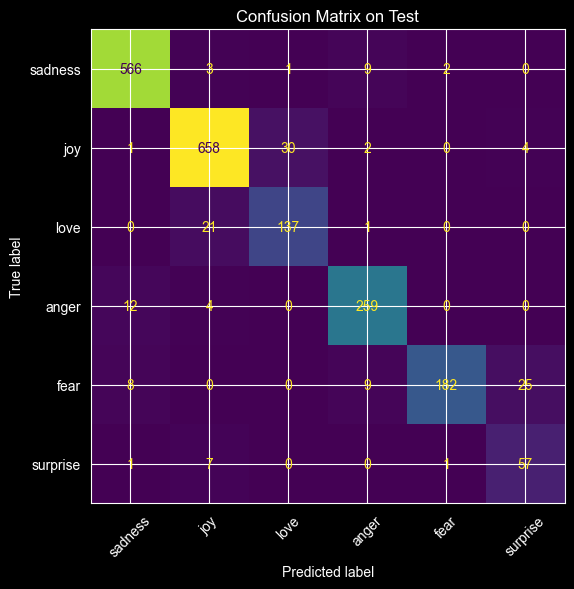

Saved: artifacts/sample_predictions.csv
Saved: artifacts/confusion_matrix.png


In [12]:

cm = confusion_matrix(test_true, test_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix on Test")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "confusion_matrix.png", dpi=160)
plt.show()

print("Saved:", ARTIFACTS_DIR / "sample_predictions.csv")
print("Saved:", ARTIFACTS_DIR / "confusion_matrix.png")


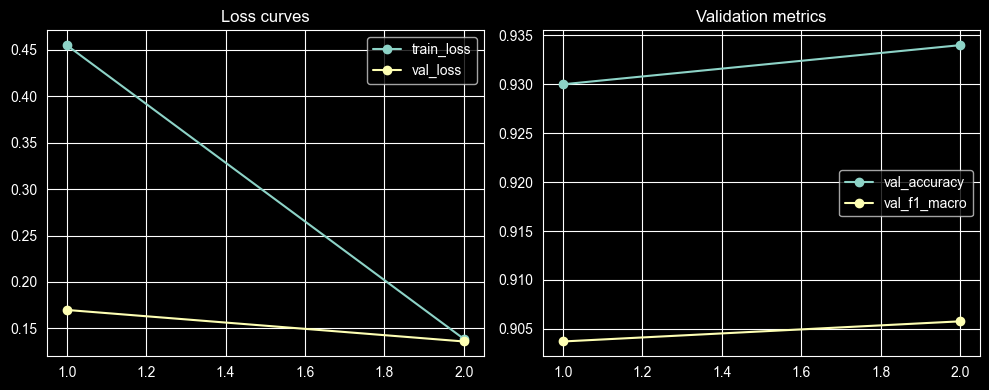

In [13]:

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(history["epoch"], history["train_loss"], marker="o", label="train_loss")
ax[0].plot(history["epoch"], history["val_loss"], marker="o", label="val_loss")
ax[0].set_title("Loss curves")
ax[0].legend()

ax[1].plot(history["epoch"], history["val_accuracy"], marker="o", label="val_accuracy")
ax[1].plot(history["epoch"], history["val_f1_macro"], marker="o", label="val_f1_macro")
ax[1].set_title("Validation metrics")
ax[1].legend()

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "training_curves.png", dpi=160)
plt.show()
